In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_datalo = f'../data/quaia_G20.0.fits'
fn_datahi = f'../data/quaia_G20.5.fits'

fn_datalo_zbin0 = f'../data/quaia_G20.0_zsplit2bin0.fits'
fn_datalo_zbin1 = f'../data/quaia_G20.0_zsplit2bin1.fits'

fn_datahi_zbin0 = f'../data/quaia_G20.5_zsplit2bin0.fits'
fn_datahi_zbin1 = f'../data/quaia_G20.5_zsplit2bin1.fits'

fn_randlo = f'../data/randoms/random_G20.0_10x.fits'
fn_randhi = f'../data/randoms/random_G20.5_10x.fits'

fn_randlo_zbin0 = f'../data/randoms/random_G20.0_zsplit2bin0_10x.fits'
fn_randlo_zbin1 = f'../data/randoms/random_G20.0_zsplit2bin1_10x.fits'

fn_randhi_zbin0 = f'../data/randoms/random_G20.5_zsplit2bin0_10x.fits'
fn_randhi_zbin1 = f'../data/randoms/random_G20.5_zsplit2bin1_10x.fits'

In [4]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

In [5]:
fn_sello_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin0.fits'
fn_sello_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.0_zsplit2bin1.fits'

fn_selhi_zbin0 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin0.fits'
fn_selhi_zbin1 = f'../data/maps/selection_function_NSIDE64_G20.5_zsplit2bin1.fits'

## Parameters

In [6]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [7]:
G_hi = 20.5
G_lo = 20.0

In [8]:
nthreads = 18

In [9]:
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

In [10]:
selfunc_hi_zbin0 = hp.fitsfunc.read_map(fn_selhi_zbin0)
selfunc_hi_zbin1 = hp.fitsfunc.read_map(fn_selhi_zbin1)

In [11]:
mask_type = 'selfunc'

# Visuals

In [12]:
tab_datalo, pixel_indices_datalo_mask, N_datalo_mask, mask_datalo = quaia.read(f'../data/quaia_G20.0.fits', G_lo, fn_sello, mask_type = 'selfunc')

Number of data sources: 755850
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [13]:
cmap_reds = sns.color_palette("Reds_r", as_cmap = True)
cmap_blues = sns.color_palette("Blues_r", as_cmap = True)

In [14]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
OrderedDict([('NAME', '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog'), ('ABBRV', 'Quaia')])
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


In [15]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

In [16]:
blue = np.mean(cmap_blue, axis = 0)
red = np.mean(cmap_red, axis = 0)

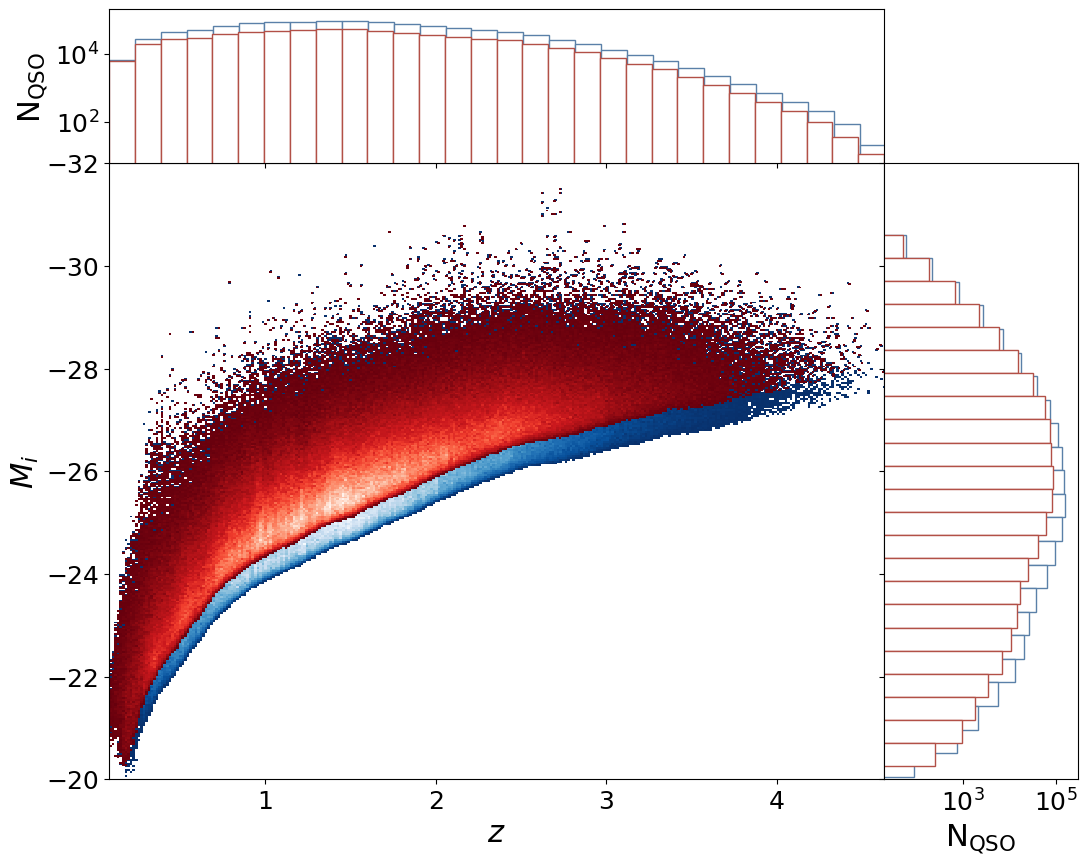

In [17]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
quaia.absolute(tab_datalo, G_lo)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap_blues, bins = 300, 
                                       cmin = 1)
h1, xedges, yedges, image = ax1.hist2d(tab_datalo['redshift_quaia'][mask_datalo], tab_datalo['M_i'][mask_datalo], cmap = cmap_reds, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = blue, bins = 30)
ax2.hist(tab_datalo['redshift_quaia'][mask_datalo], color = 'white', edgecolor = red, bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = blue, orientation = 'horizontal', bins = 25)
ax3.hist(tab_datalo['M_i'][mask_datalo], color = 'white', edgecolor = red, orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in 2 mag L bins

In [19]:
L_bins = np.linspace(-32,-20,5)
L_array = range(len(L_bins)-1)
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_array)))[::-1]
cmaps = [cmap_red, cmap_blue]
tabs = [tab_datalo[mask_datalo], tab_datahi[mask_datahi]]
G_array = [G_lo, G_hi]
labels = ['${}<M_i\leq{}$'.format(L, L+3) for L in L_bins[:-1]]

_G20.0_Lmin-32.0Lmax-29.0


FileNotFoundError: [Errno 2] No such file or directory: '../data/randoms/random_G20.0_Lmin-32.0Lmax-29.0_25x.fits'

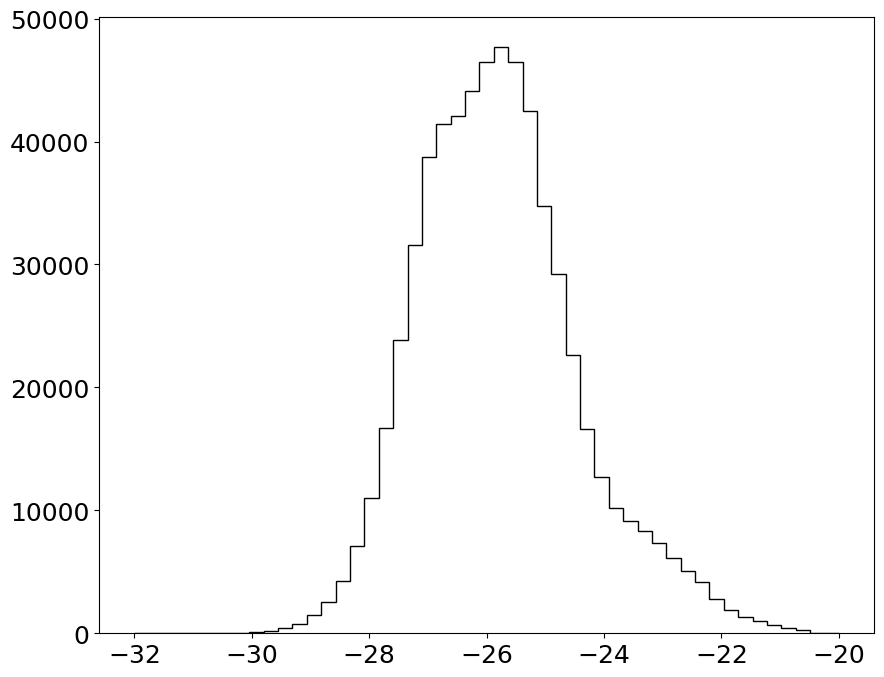

In [22]:
# plot data
bins = np.linspace(-32,-20)

# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)
locs = ['center right', 'center left']
x = [-0.15, 1]
for i in range(len(G_array)):

    ax1 = fig.add_subplot(gs[i])
    ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')

    for j in range(len(labels)):
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G_array[i], j, True, 'L', bins = L_bins,
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)
        ax1.hist(tab_datahi_mask_zbin0['M_i'], label = labels[j], bins = bins, color = cmaps[i][j])

    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel('$M_i$')
    ax1.set_yscale('log')
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i>0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel('$N_\mathrm{QSO}$')

plt.show()

In [26]:
# for Lbin in L_array:
#     test = Table.read('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/data/quaia_G20.5_Lsplit3bin{}.fits'.format(i))
#     print(len(test))
    # print(N_datahi_mask_zbin0/len(test))

## $\xi(s)$

In [27]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [28]:
# plot data
# bins = np.linspace(-32,-20)
cf = {G_lo: [], G_hi: []}

# # plot!
# fig = plt.figure(figsize = (20, 8), layout = 'constrained')
# gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):

    # fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_array[i])
    # selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

    # ax1 = fig.add_subplot(gs[i])
    # ax1.hist(tabs[i]['M_i'], bins=bins, histtype = 'step', color='black')

    for j in range(len(labels)):
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G_array[i], j, True, 'L', bins = L_bins,
                                                                                        tab_gcat_type = 'data', method = 'minmax', fac_rand = 25)
        # ax1.hist(tab_datahi_mask_zbin0['M_i'], label = labels[j+1], bins = bins, color = cmaps[i][j+1])
        
        cf[G_array[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins))
        # print(label, np.min(tab_datahi_mask_zbin0['M_i']), np.max(tab_datahi_mask_zbin0['M_i']), '\n')

#     ax1.set_title('$G<{}$'.format(G_array[i]))
#     ax1.set_xlabel('$M_i$')
#     ax1.set_yscale('log')
#     # ax1.legend(loc = 'outside lower center')
#     if i>0:
#         ax1.set_yticklabels([])
#     else:
#         ax1.set_ylabel('$N_\mathrm{QSO}$')

# fig.legend(loc = 'outside lower center')
# plt.show()

_G20.0_Lmin-32.0Lmax-30.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lmin-30.0Lmax-28.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lmin-28.0Lmax-26.0


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-24.0Lmax-22.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-22.0Lmax-20.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


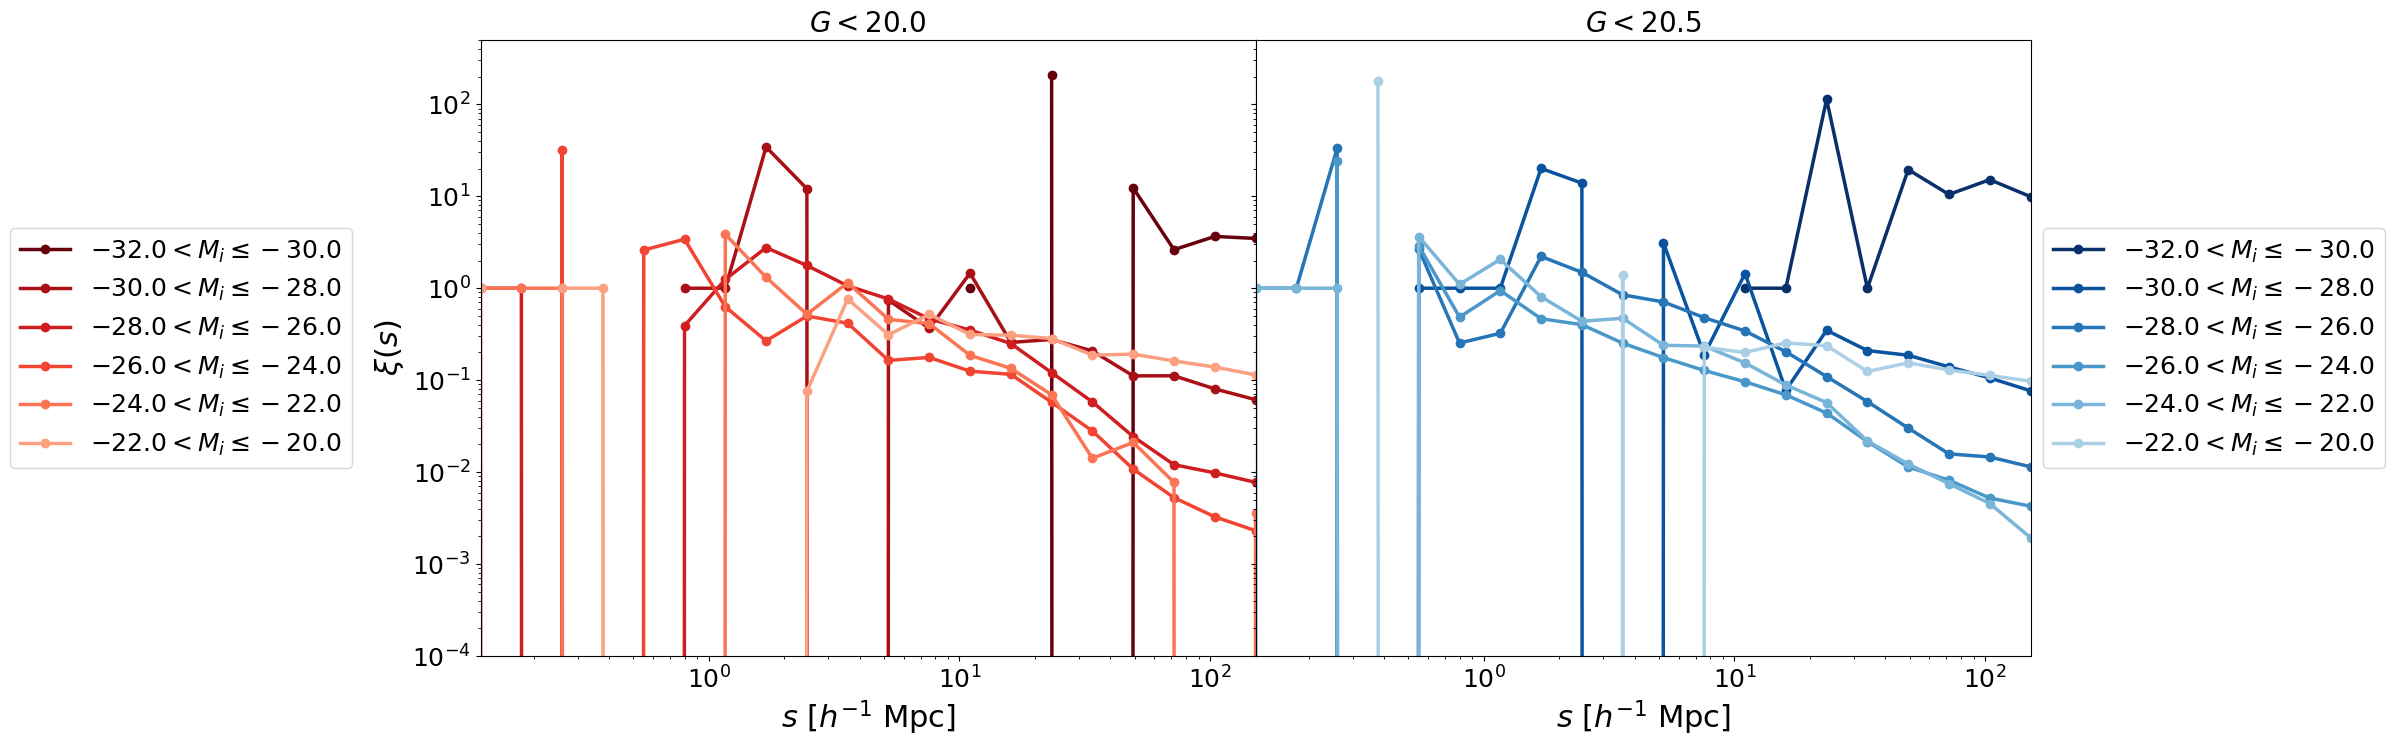

In [29]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    ax1 = fig.add_subplot(gs[i])
    for Lbin, label in zip(L_array, labels):
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.set_title('$G<{}$'.format(G_array[i]))
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-4, 5e2)
        ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
        if i==0:
            ax1.set_ylabel(r"$\xi(s)$")
        else:
            ax1.set_yticklabels([])

plt.show()

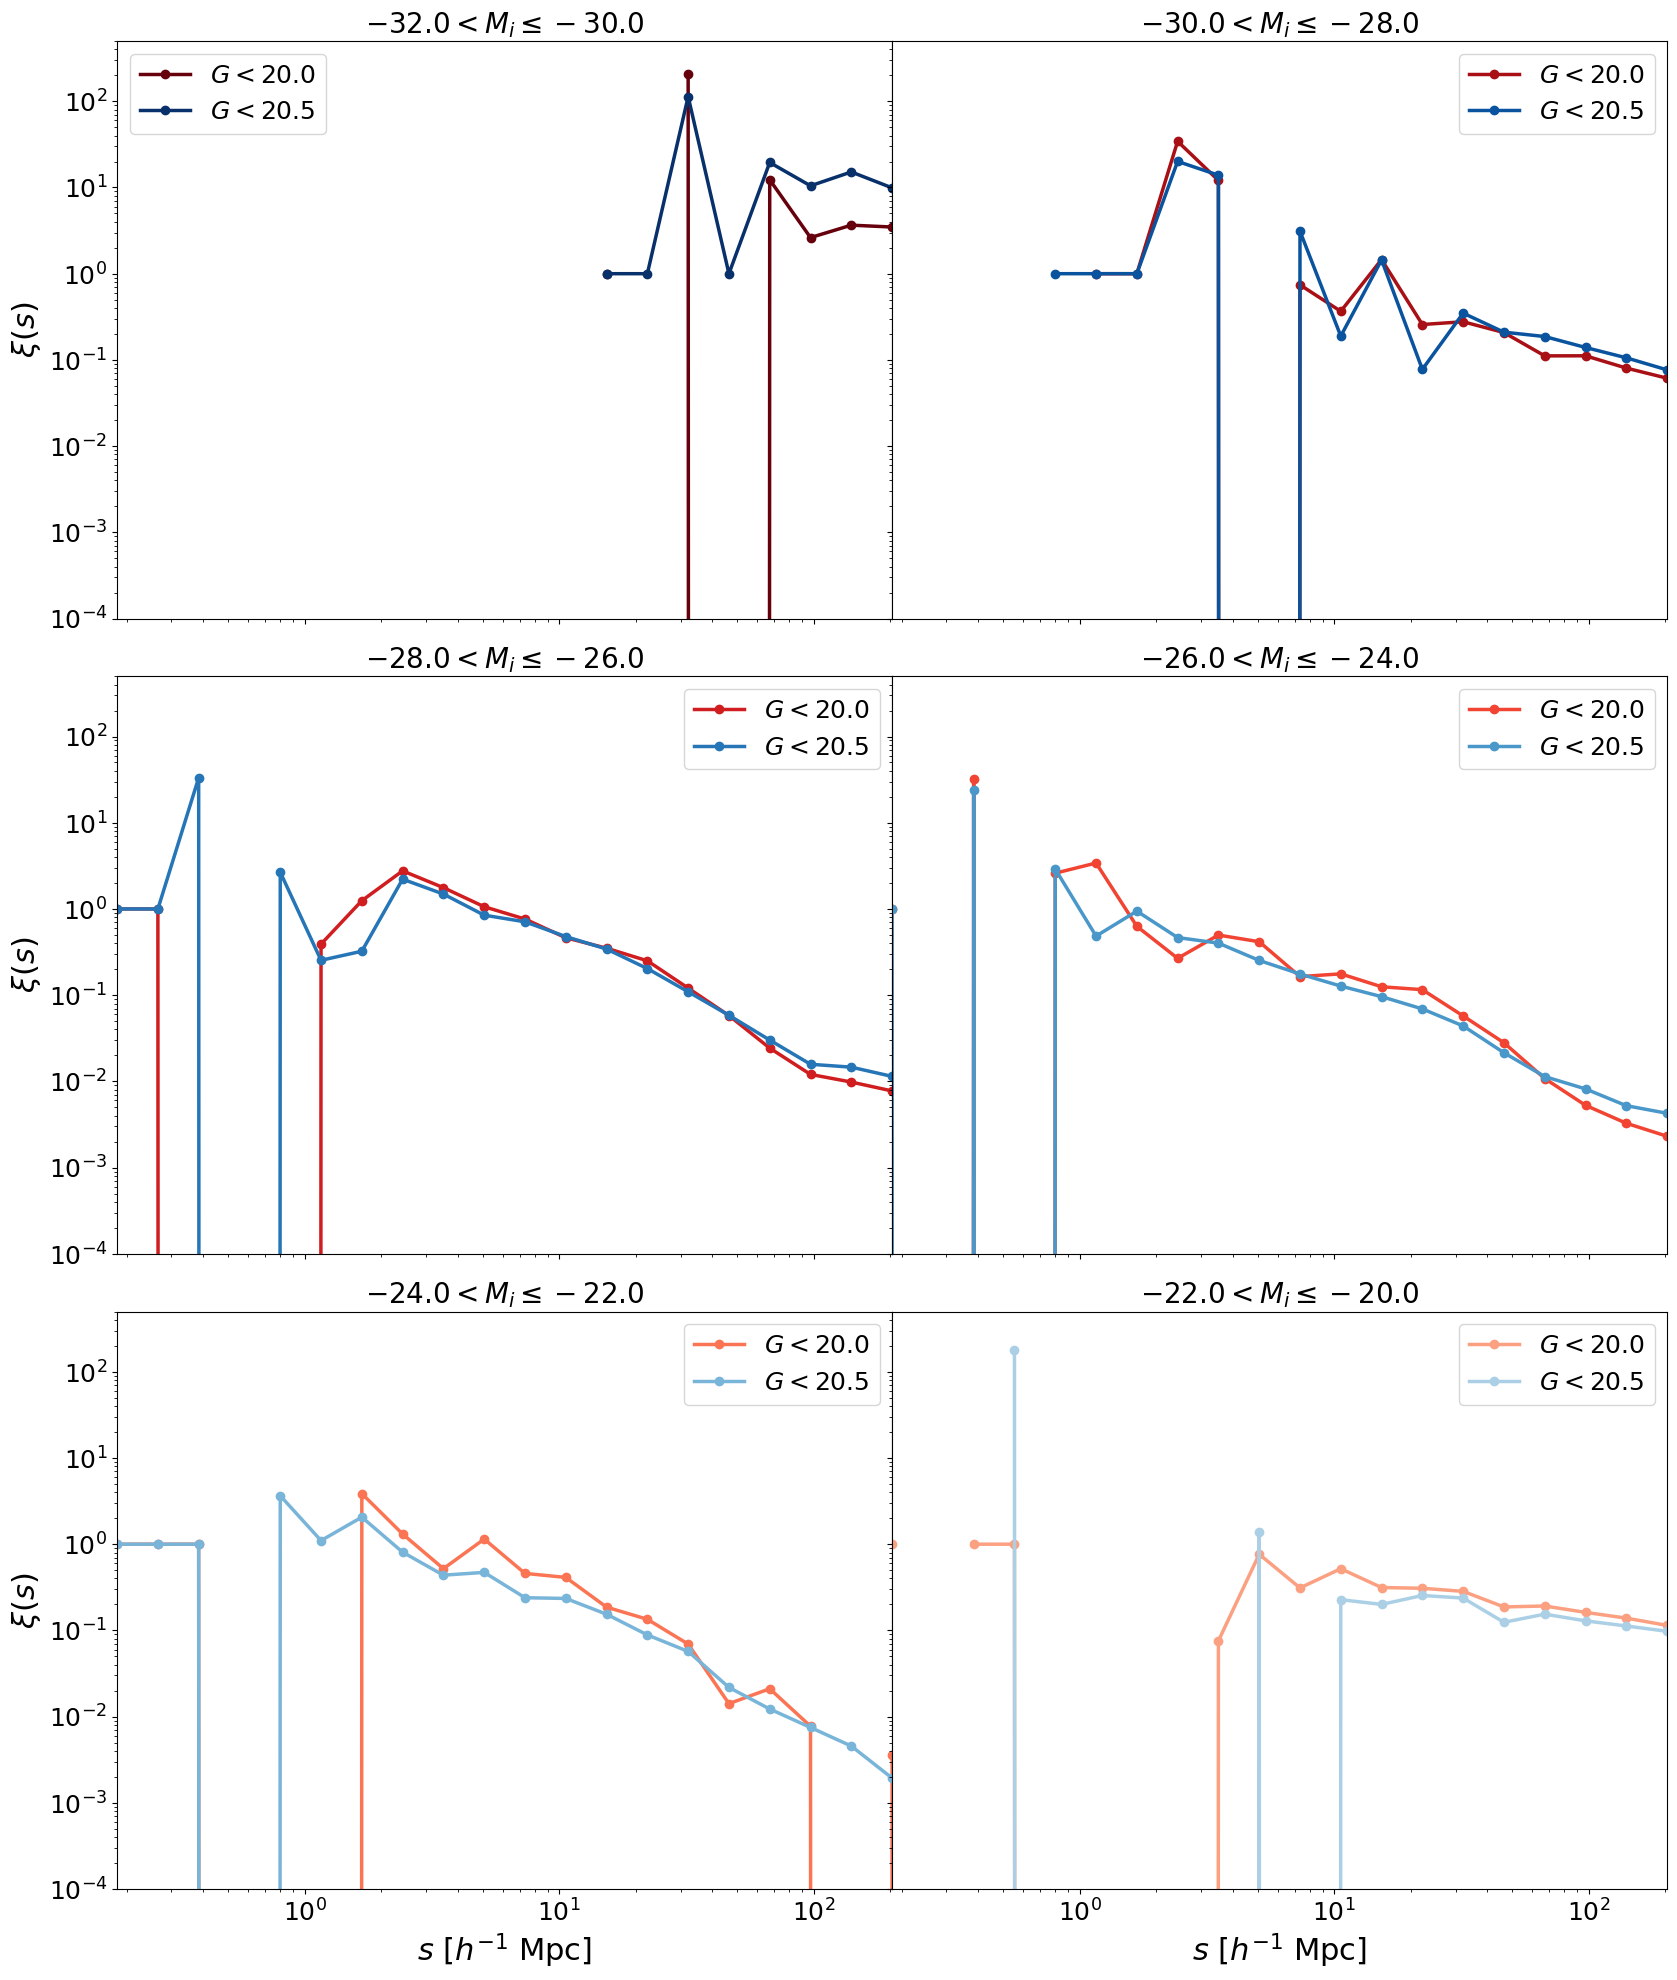

In [39]:
# plot!
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(3, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):
        
        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 5e2)
    ax1.legend()
    if Lbin > 3:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    else: 
        ax1.set_xticklabels([])
    if Lbin%2==0:
        ax1.set_ylabel(r"$\xi(s)$")
    else:
        ax1.set_yticklabels([])

plt.show()

## $w_p(r_p)$

In [31]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

In [32]:
pimax = 80 # 40 # 5000.0 # 40.0

In [33]:
# plot data
# bins = np.linspace(0.08, 4.6)
wp, rpavg = {20.0: [], 20.5: []}, {20.0: [], 20.5: []}
for G in G_array:

    for Lbin in L_array:
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _ = quaia.make_bins(G, Lbin, True, 'L', bins = L_bins, fac_rand = 25, 
                                                                                        method = 'minmax', tab_gcat_type = 'data')

        wp_datahi_zbin0, rpavg_datahi_zbin0 = quaia.wp_rp(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, 
                                                           nbins = nbins, pimax = pimax)
        wp[G].append(wp_datahi_zbin0)
        rpavg[G].append(rpavg_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-30.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.0_Lmin-30.0Lmax-28.0


/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:657: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])
/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts/quaia.py:657: RuntimeWarning: invalid value encountered in scalar divide
  rpavg = [np.sum((DD_counts['rpavg']*DD_counts['npairs'])[DD_counts['rmin']==i])/np.sum(DD_counts['npairs'][DD_counts['rmin']==i])


_G20.0_Lmin-28.0Lmax-26.0


...

/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-24.0Lmax-22.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


_G20.5_Lmin-22.0Lmax-20.0


/home/groups/tabel/mahlet/quaia-env/lib/python3.10/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


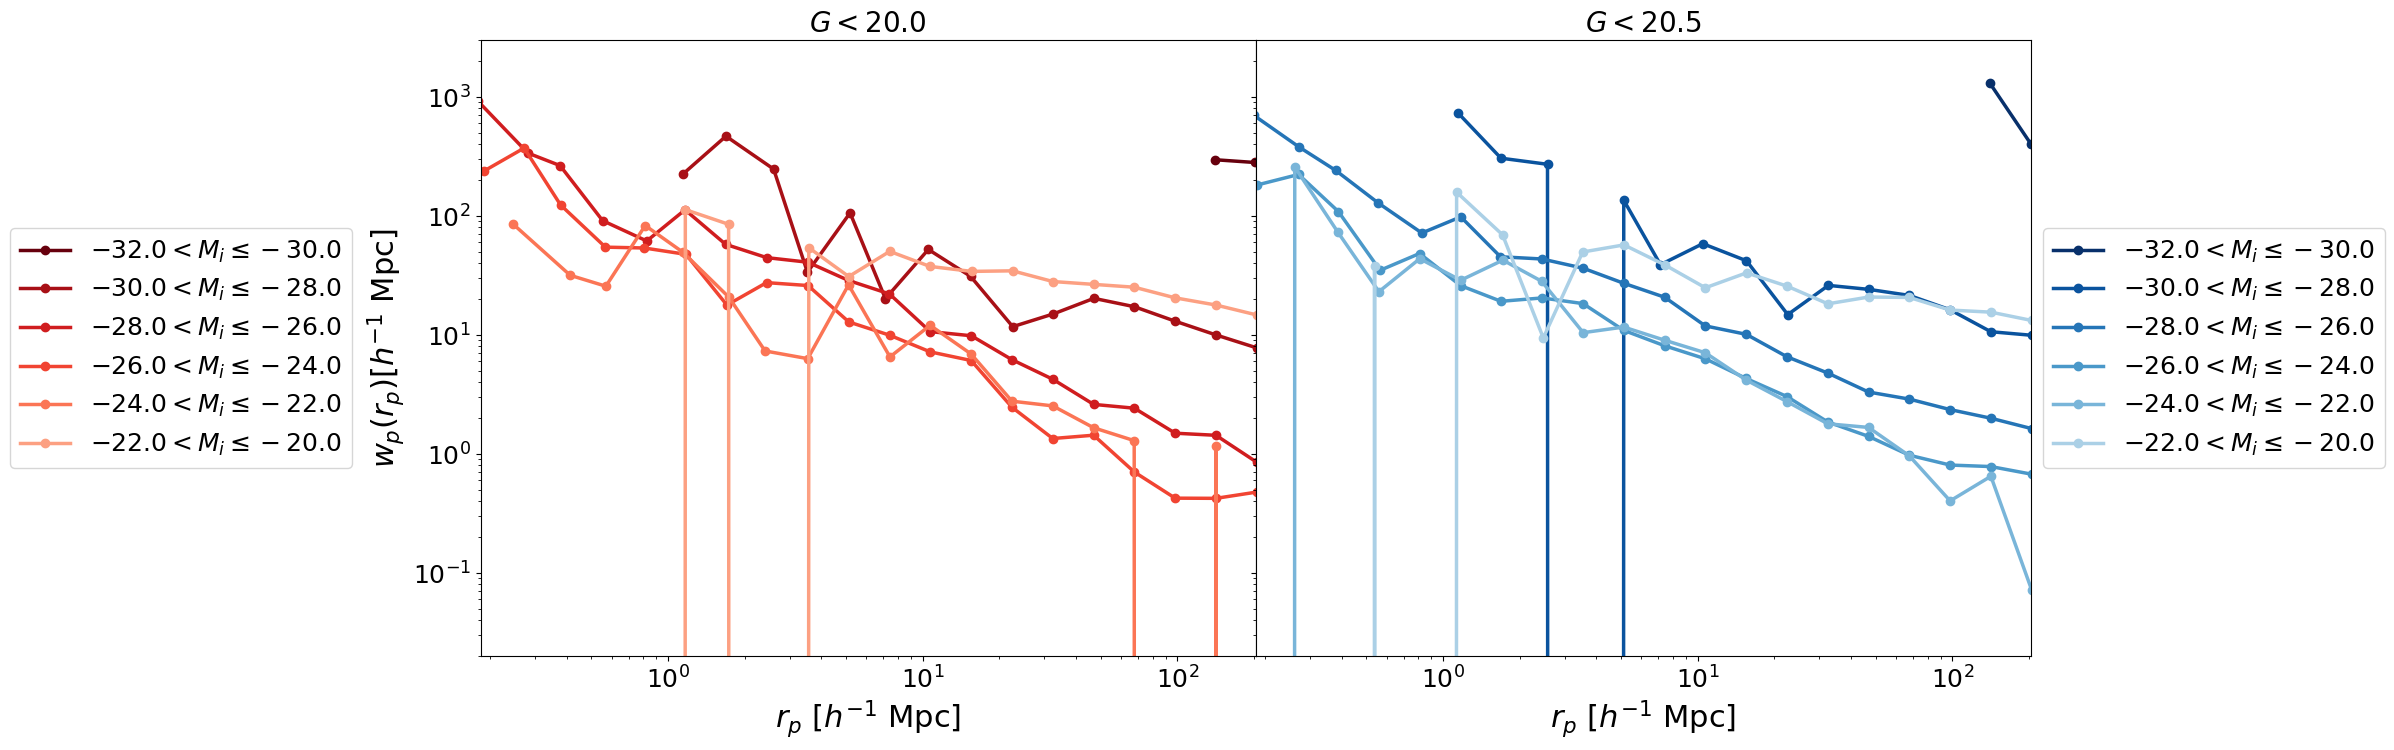

In [34]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-2, 3e3)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

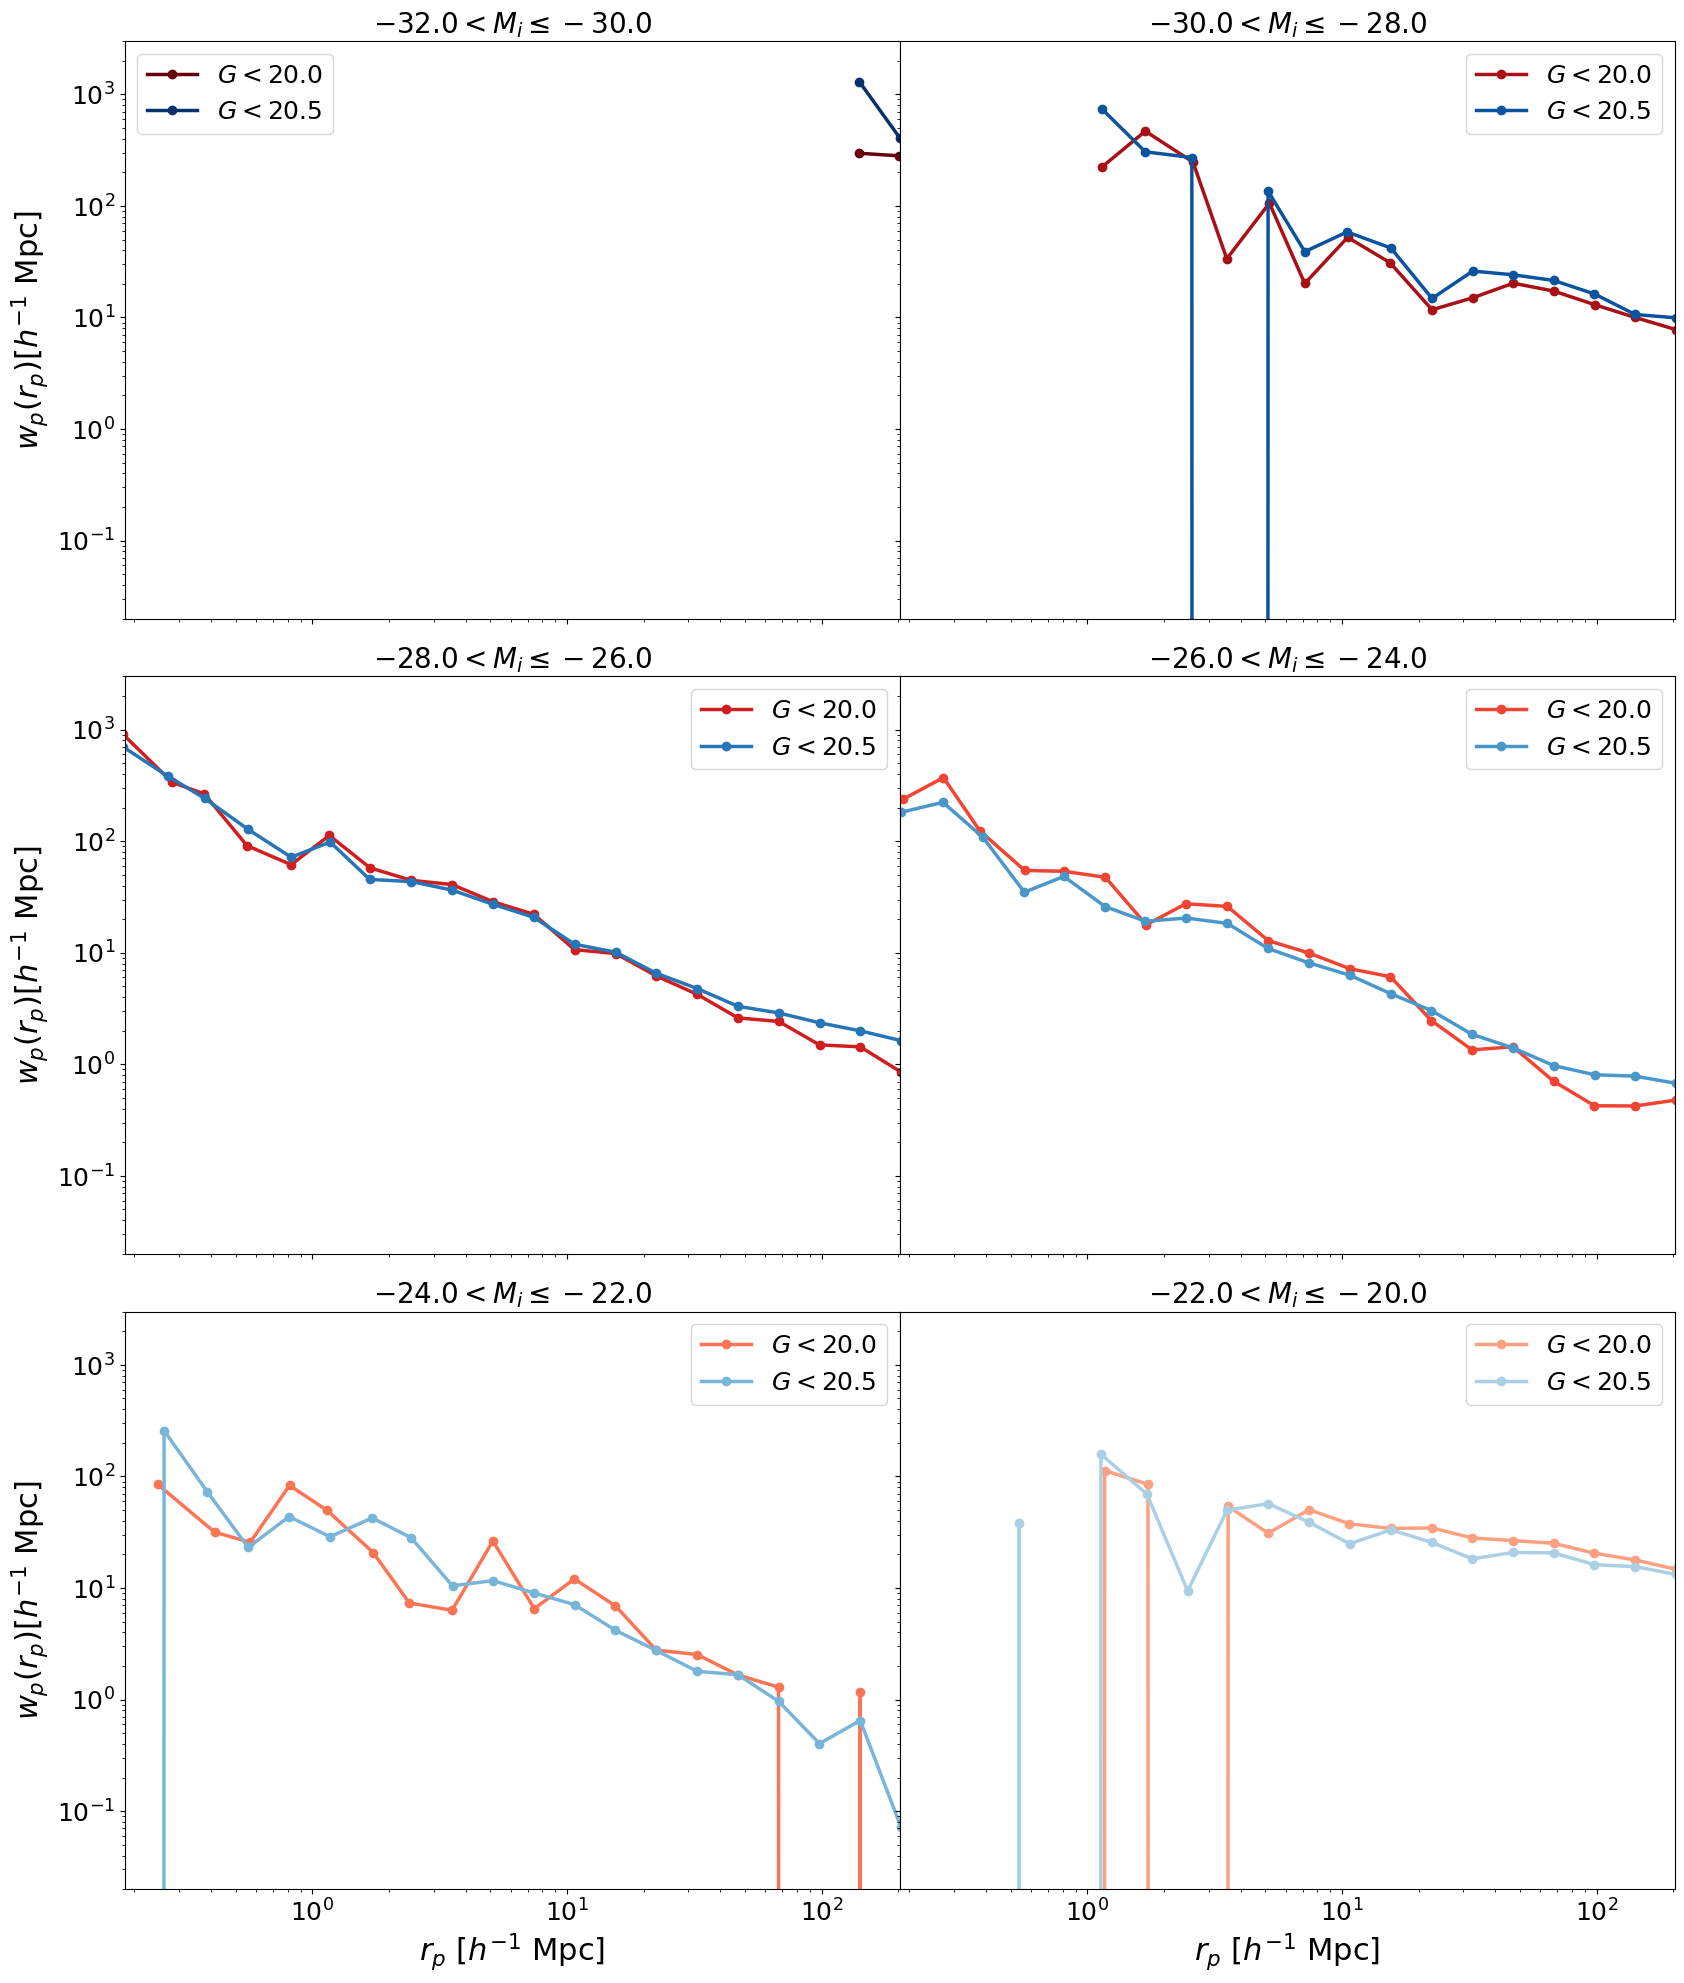

In [40]:
# plot!
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(3, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(2e-2, 3e3)
    ax1.legend()
    if Lbin>3:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])
    if Lbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)[h^{-1}$ Mpc]")
    else:
        ax1.set_yticklabels([])

plt.show()

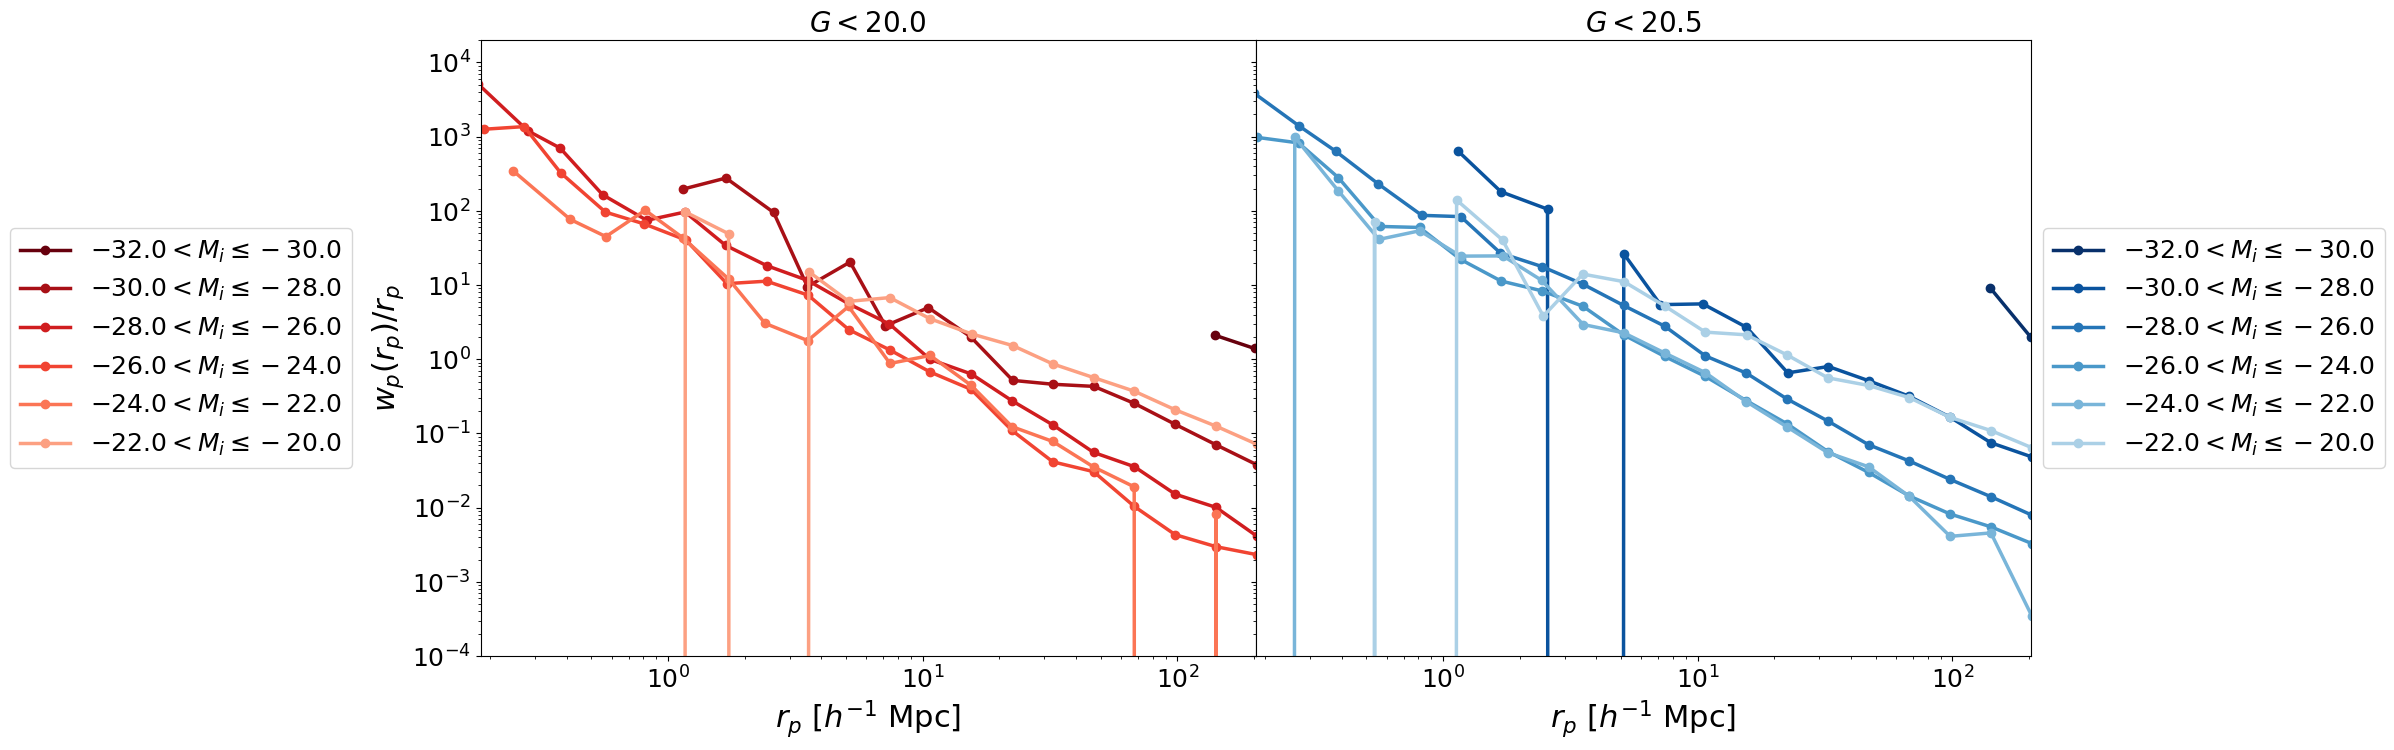

In [41]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

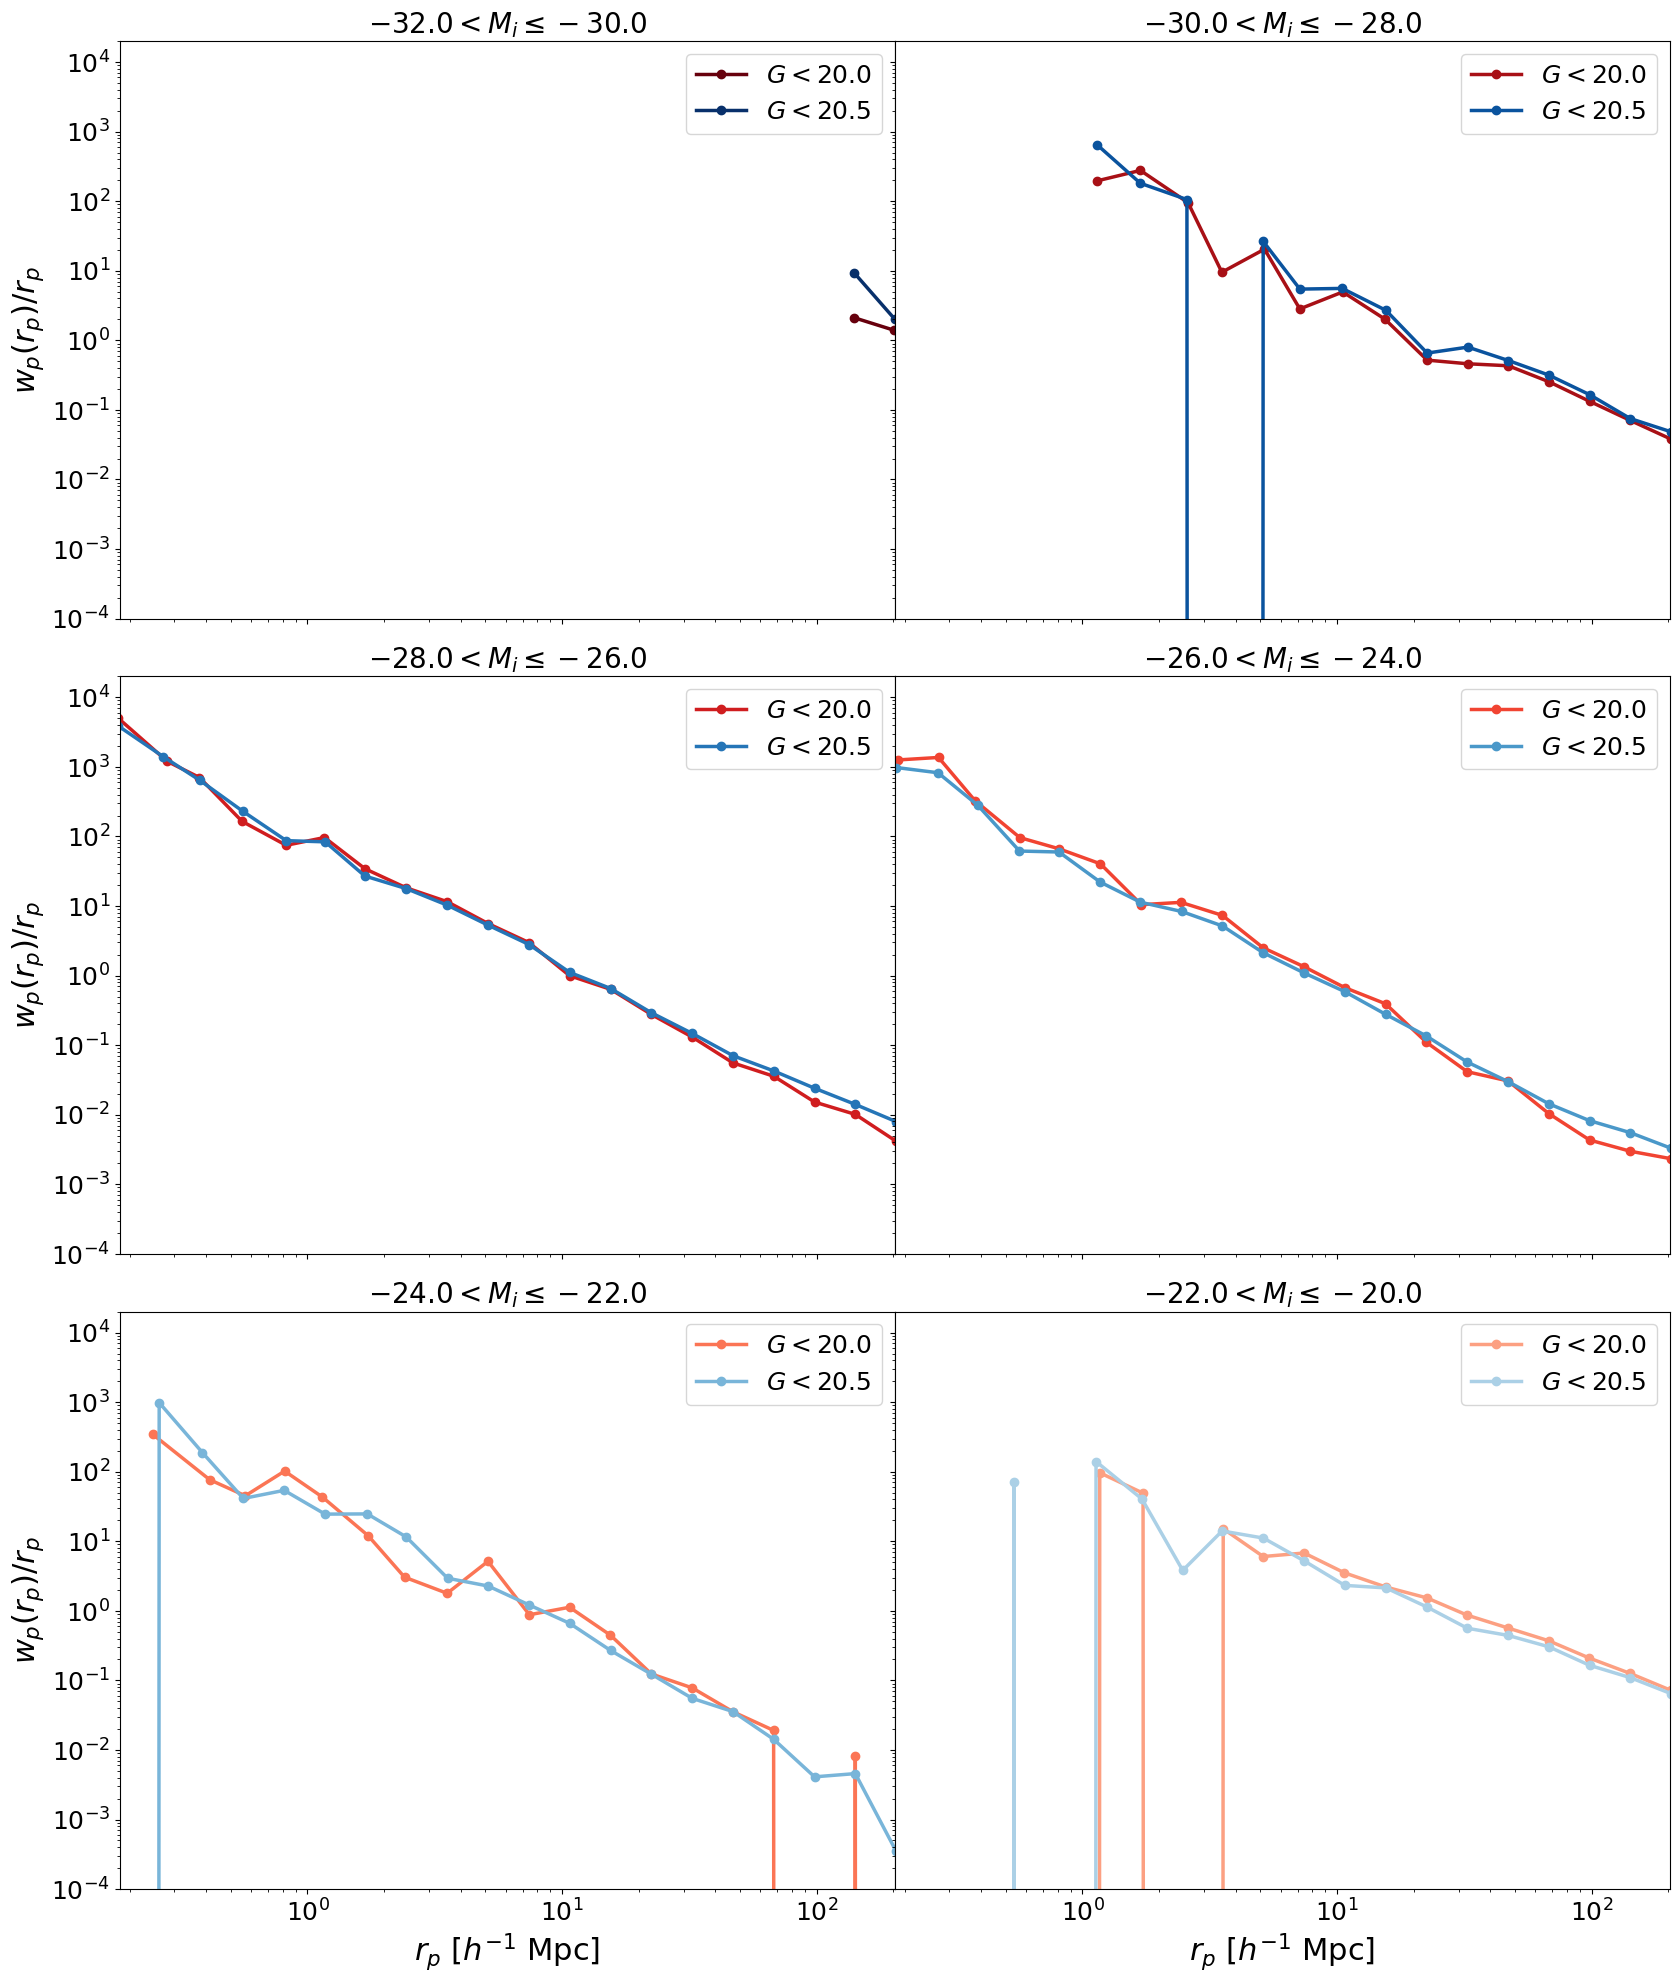

In [42]:
# plot!
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(3, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend()
    if Lbin%2==0:
        ax1.set_ylabel(r"$w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>3:
        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

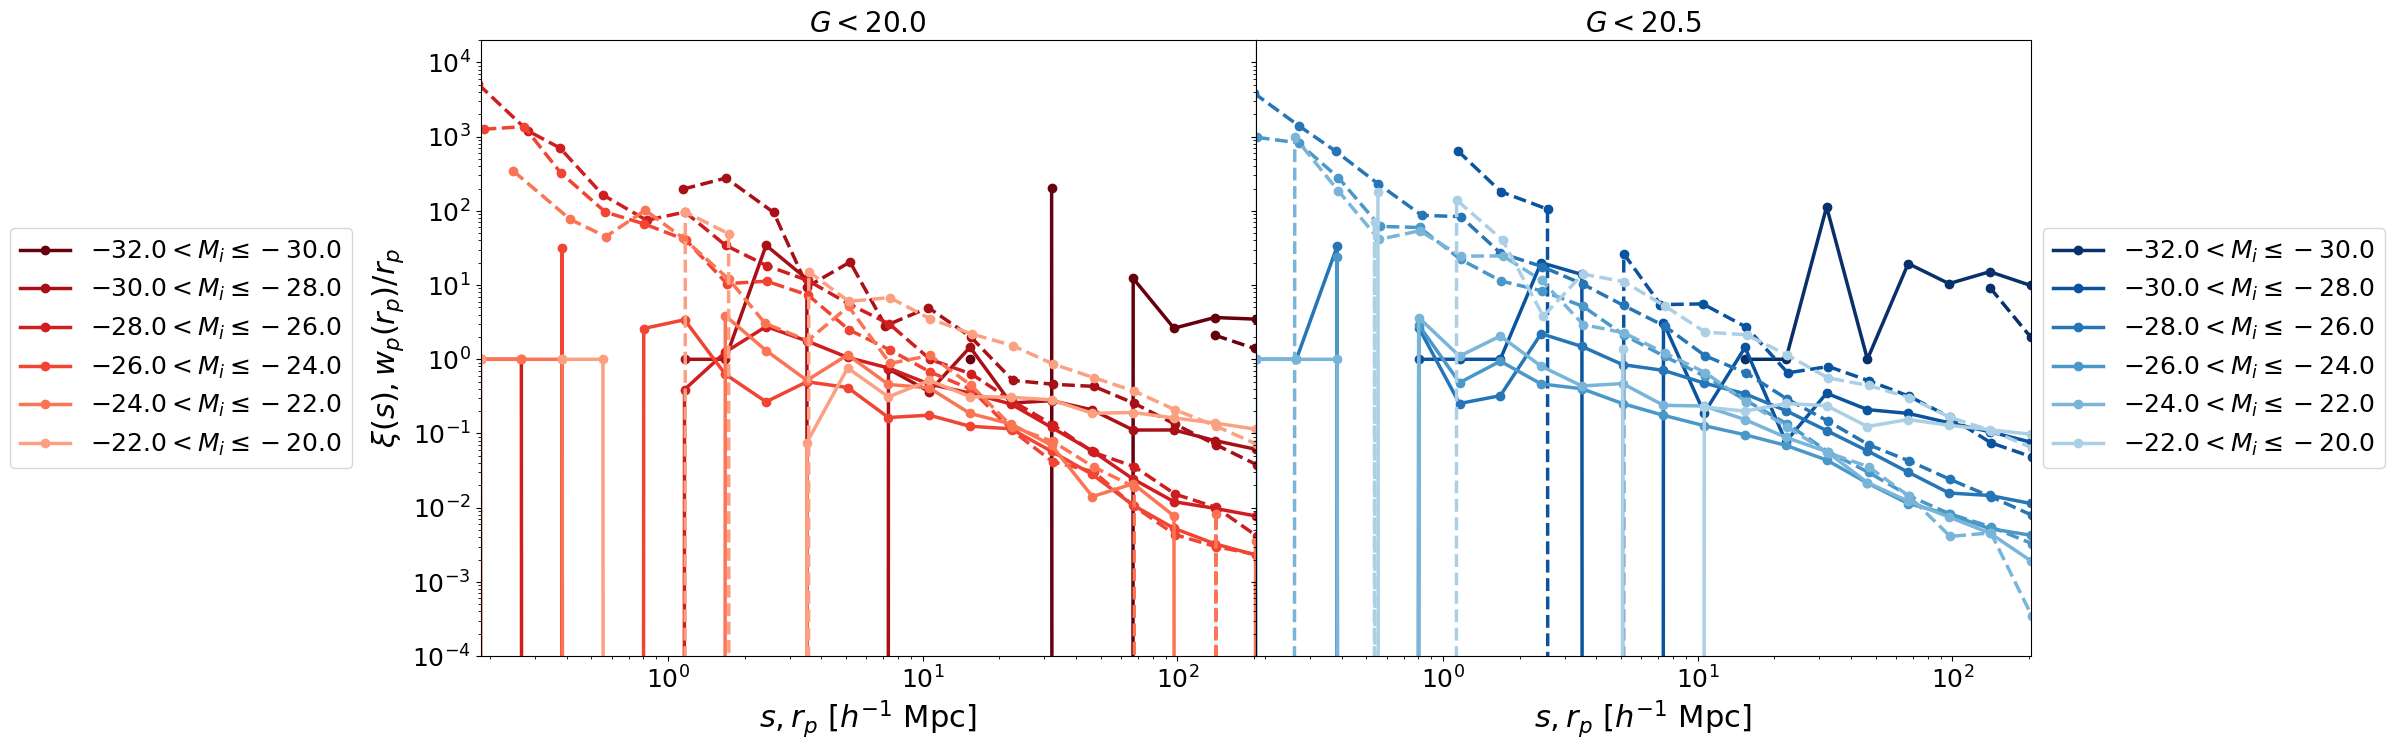

In [46]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

# G_array = [20.0, 20.5]
for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):
        
        ax1.plot(quaia.recenter(rbins), cf[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', color = cmaps[i][Lbin])
        ax1.plot(rpavg[G_array[i]][Lbin], wp[G_array[i]][Lbin]/rpavg[G_array[i]][Lbin], linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin], linestyle = '--')
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])

plt.show()

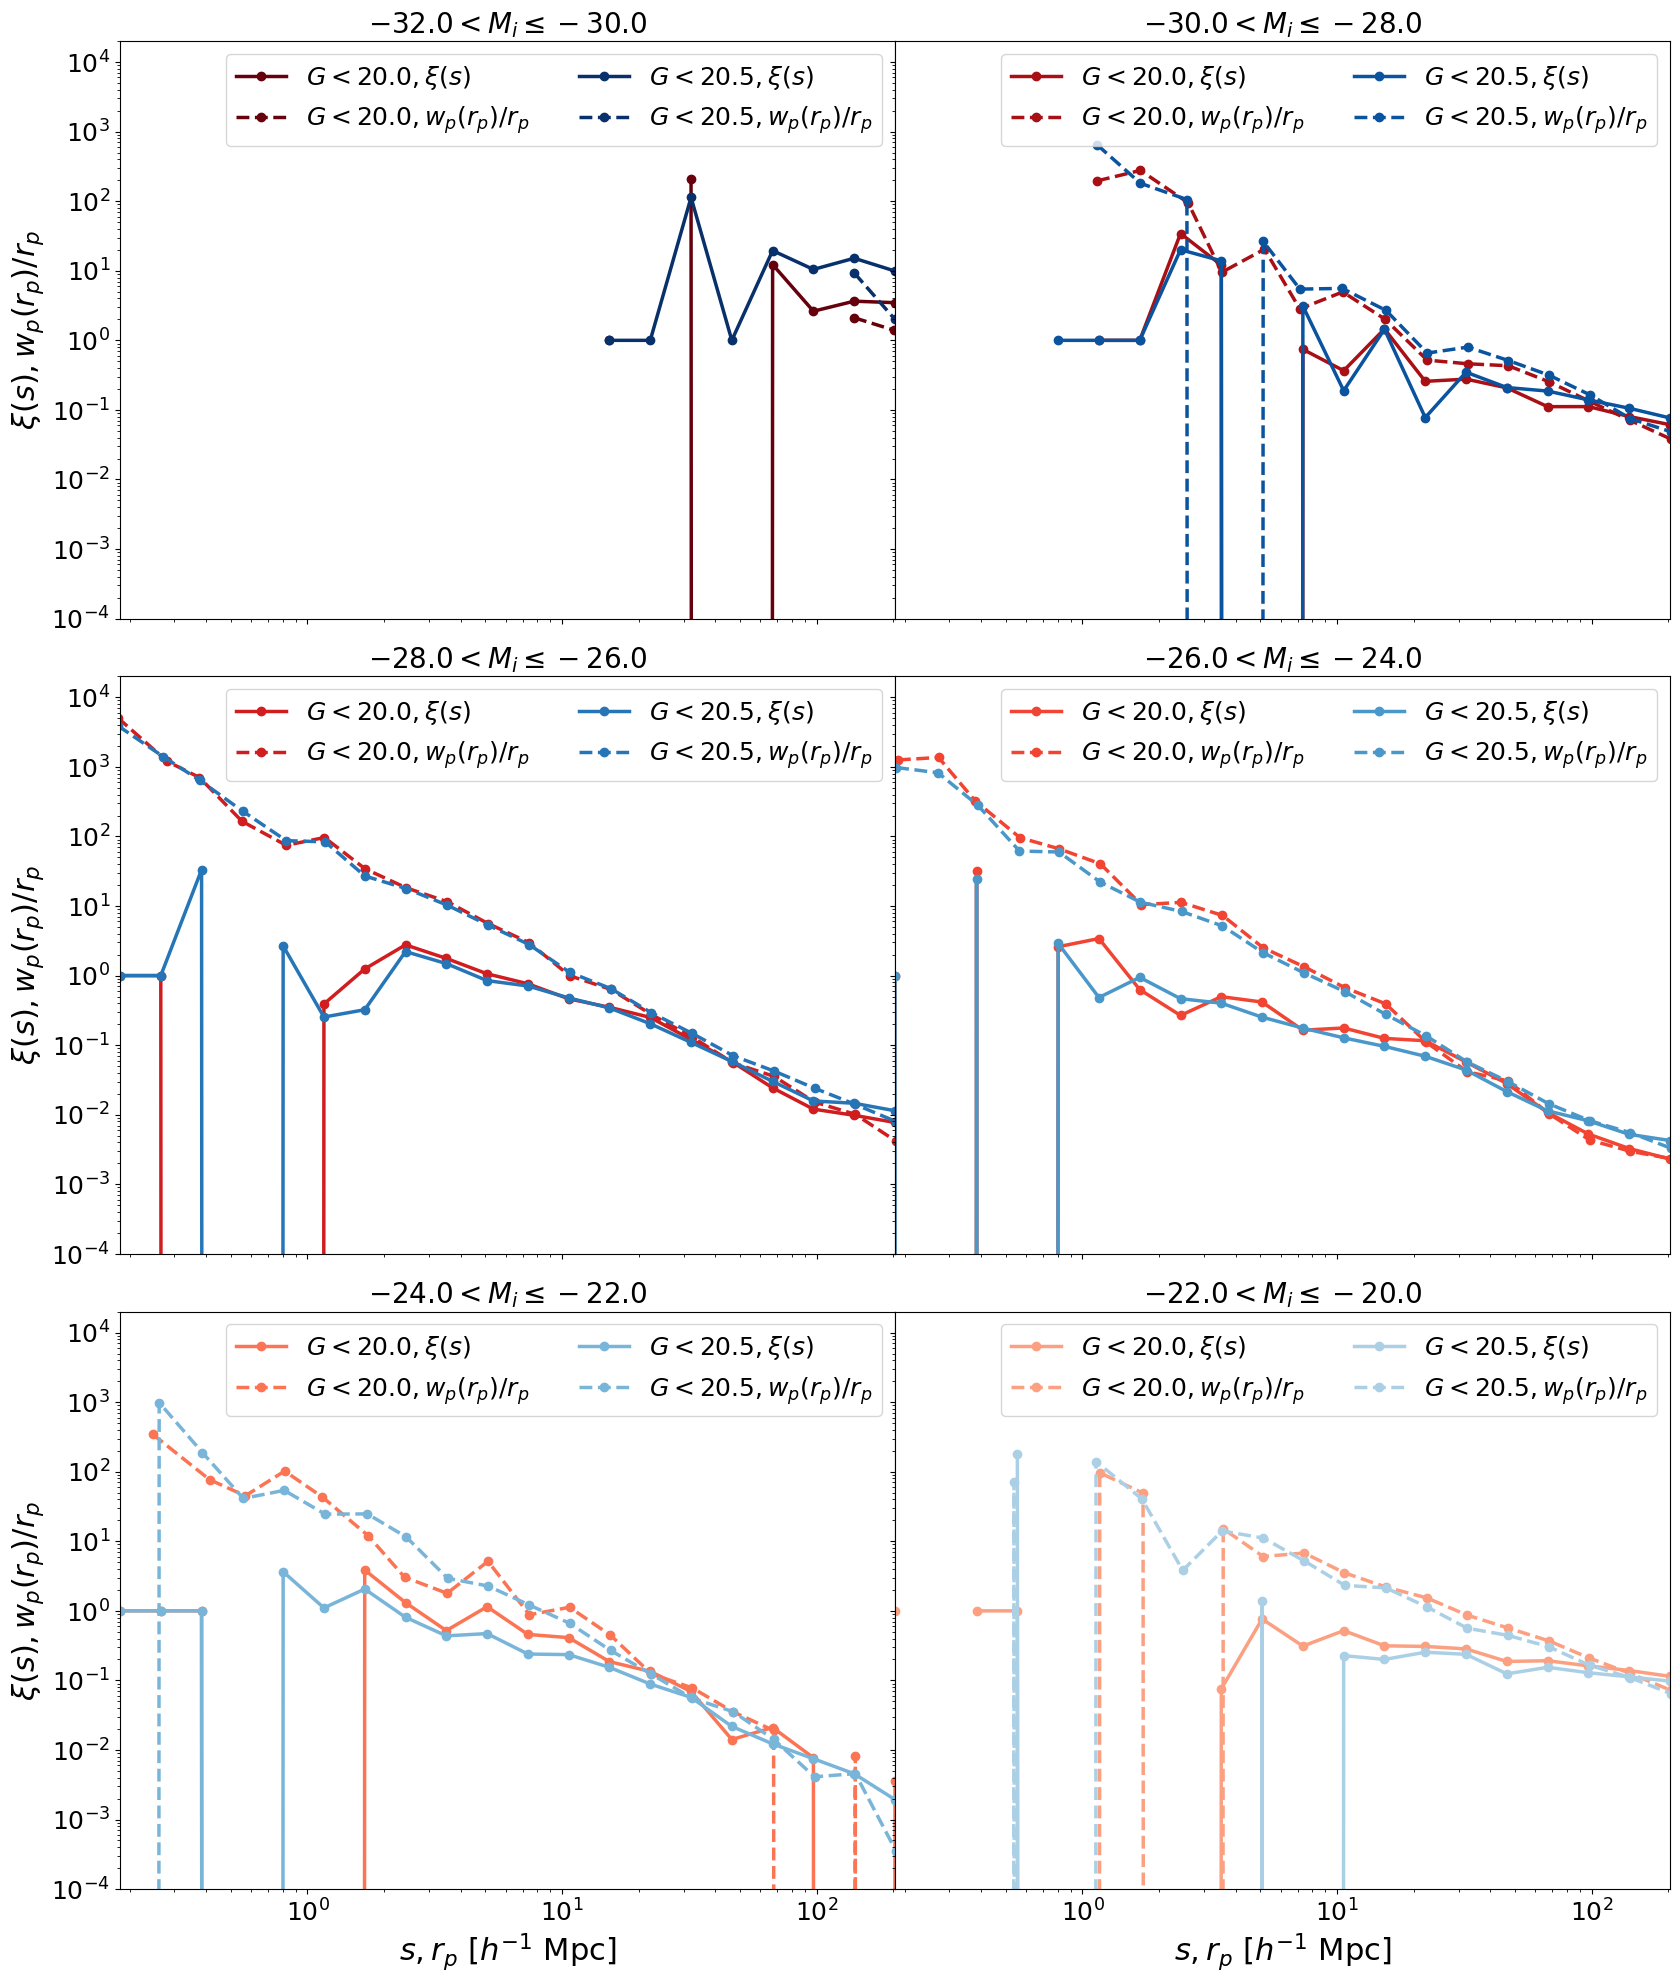

In [49]:
# plot!
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(3, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(rbins), cf[G][Lbin], label = '$G<{}, \\xi(s)$'.format(G), linewidth = 2.5, marker = 'o', color = cmap[Lbin])
        ax1.plot(rpavg[G][Lbin], wp[G][Lbin]/rpavg[G][Lbin], label = '$G<{}, w_p(r_p)/r_p$'.format(G), linewidth = 2.5, marker = 'o', linestyle = '--',
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-4, 2e4)
    ax1.legend(ncol = 2)
    if Lbin%2==0:
        ax1.set_ylabel(r"$\xi(s), w_p(r_p)/r_p$")
    else:
        ax1.set_yticklabels([])
    if Lbin>3:
        ax1.set_xlabel(r'$s, r_p$ $[h^{-1}$ Mpc]') # projected
    else:
        ax1.set_xticklabels([])

plt.show()

## $w(\theta)$

In [50]:
# Create the bins array
# thetabins = np.logspace(np.log10(0.1), np.log10(10), 15) 
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

In [ ]:
# plot data
wtheta = {G_lo: [], G_hi: []}
for G in G_array:

    for Lbin in L_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, _, _, _ = quaia.make_bins(G, Lbin, True, 'L', bins = L_bins, fac_rand = 25, method = 'minmax',
                                                                                tab_gcat_type = 'data', z = False)

        wtheta_datahi_zbin0 = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
        wtheta[G].append(wtheta_datahi_zbin0)

_G20.0_Lmin-32.0Lmax-30.0
DD: 0.00047099999999999996
DR: 0.002129
RR: 0.002547
_G20.0_Lmin-30.0Lmax-28.0
DD: 0.015416
DR: 0.647805
RR: 6.262212
_G20.0_Lmin-28.0Lmax-26.0
DD: 1.03475
DR: 57.189735
RR: 676.639744
_G20.0_Lmin-26.0Lmax-24.0
DD: 0.7212189999999999
DR: 38.153869
RR: 467.904128
_G20.0_Lmin-24.0Lmax-22.0
DD: 0.01808
DR: 0.709037
RR: 6.93437
_G20.0_Lmin-22.0Lmax-20.0
DD: 0.005221
DR: 0.06917899999999999
RR: 0.312814
_G20.5_Lmin-32.0Lmax-30.0
DD: 0.000434
DR: 0.0024749999999999998
RR: 0.0030039999999999997
_G20.5_Lmin-30.0Lmax-28.0
DD: 0.01698
DR: 0.6996340000000001
RR: 6.486616
_G20.5_Lmin-28.0Lmax-26.0
DD: 2.010971
DR: 106.06215


In [ ]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2, wspace = 0)

for i in range(len(G_array)):
    
    ax1 = fig.add_subplot(gs[i])
    
    for Lbin, label in zip(L_array, labels):

        ax1.plot(quaia.recenter(thetabins), wtheta[G_array[i]][Lbin], label = label, linewidth = 2.5, marker = 'o', 
                 color = cmaps[i][Lbin])
        
    ax1.set_title('$G<{}$'.format(G_array[i]))
    ax1.set_xlabel(r'$\theta^{\circ}$')
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 7e1)
    ax1.legend(loc = locs[i], bbox_to_anchor = (x[i], 0.5))
    if i==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()

In [ ]:
# plot!
fig = plt.figure(figsize = (20, 24))
gs = gridspec.GridSpec(3, 2, wspace = 0, hspace = 0.1)

for Lbin, title in zip(L_array, labels):
    
    ax1 = fig.add_subplot(gs[Lbin])
    
    for G, cmap in zip(G_array, cmaps):

        ax1.plot(quaia.recenter(thetabins), wtheta[G][Lbin], label = '$G<{}$'.format(G), linewidth = 2.5, marker = 'o', 
                 color = cmap[Lbin])
        
    ax1.set_title(title)
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-6, 7e1)
    ax1.legend()
    if Lbin>3:
        ax1.set_xlabel(r'$\theta^{\circ}$')
    else:
        ax1.set_xticklabels([])
    if Lbin%2==0:
        ax1.set_ylabel(r"$w(\theta)$")
    else:
        ax1.set_yticklabels([])

plt.show()